In [231]:
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import h5py
import lightning as L
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import sys
import torchvision.transforms as transforms
from PIL import Image
import random
import matplotlib.pyplot as plt
import logging
from sklearn.model_selection import train_test_split
import mlflow

sys.path.append("../../../../donut/src/test/")
from common.config import cfg


In [59]:
logging.basicConfig(
    filename="./logs/ImageLightningDataset.log",
    encoding="utf-8",
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO,
)

In [60]:
batch_size=cfg.batch_size
ds_multiplier=cfg.ds_multiplier
print("batch_size:",batch_size)
print("ds_multiplier:",ds_multiplier)

batch_size: 32
ds_multiplier: 2


In [61]:
# label mapping

label_encoder = {
    "dot": cfg.dot,
    "scatter": cfg.scatter,
    "horizontal_bar": cfg.horizontal_bar,
    "line": cfg.line,
    "vertical_bar": cfg.vertical_bar,
}

print(label_encoder)

{'dot': 0, 'scatter': 1, 'horizontal_bar': 2, 'line': 3, 'vertical_bar': 4}


In [62]:
# GPU

has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(device)

mps


In [63]:
hdf5_file="../../../data/classificationH5/ImageTransformation.h5"

In [64]:
class ImageClsDataset(Dataset):
    def __init__(self, hdf5_file):
        '''
        hdf5_file: the path of the hdf5 dataset
        '''
        self.hdf5_file = hdf5_file
        with h5py.File(self.hdf5_file, "r") as hf:
            self.length = hf["images"].shape[0]
            # load all labels into memory at one time (high efficiency)
            self.labels = hf["labels"][:] 

    def __len__(self):
        '''
        return the number of data in the dataset
        '''
        return self.length
    
    def __getitem__(self, idx):
        with h5py.File(self.hdf5_file, "r") as hf:
            image = hf["images"][idx]
            label = hf["labels"][idx]
        
        # transform tensor and do image normalization
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label = torch.tensor(label, dtype=torch.long)
        return image, label

In [65]:
def compute_class_weights(labels):
    '''
    weighted sampling
    decreasing the influence from imbalanced datset
    param:
        labels: Dataset.labels (np.array)
    '''
    unique_labels, counts = np.unique(labels, return_counts=True)
    class_weights = {label: 1.0 / count for label, count in zip(unique_labels, counts)}
    
    sample_weights = np.array([class_weights[label] for label in labels])
    
    return sample_weights

In [66]:
# initilize the dataset
image_ds = ImageClsDataset(hdf5_file)

In [67]:
print(type[image_ds.labels])
print(len(image_ds.labels))
print(set(list(image_ds.labels)))

type[array([1, 4, 1, ..., 3, 1, 3], dtype=int32)]
60575
{0, 1, 2, 3, 4}


In [68]:
# get the sampler
sample_weights = compute_class_weights(image_ds.labels)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [69]:
sampler

In [70]:
# contruct the dataloader

# I set the num_workers=0 here, because in local env (mac os), The dataset should be defined in a seperated .py file.
# already defined the sampler, do not need to define shuffle=true right here
dataloader = DataLoader(image_ds, batch_size=batch_size, sampler=sampler, num_workers=0)

for batch_idx, (images, labels) in enumerate(dataloader):
    print(f"Batch {batch_idx+1}:")
    print(f"  Image batch shape: {images.shape}")  # (32, 3, 640, 640)
    print(f"  Label batch distribution: {np.bincount(labels.numpy())}") 
    break # check the first batch

Batch 1:
  Image batch shape: torch.Size([32, 3, 640, 640])
  Label batch distribution: [ 5  4 11  4  8]


In [71]:
# now add the data augmentation steps into dataset


class ImageClsDataset(Dataset):
    def __init__(
        self,
        hdf5_file: str,
        augment: bool = False,
        image_height: int = 224,
        image_width: int = 224,
    ):
        """
        hdf5_file: the path of the hdf5 dataset
        augment: choose if doing augmentation on image or not
        image_height | image_width: the size of the image as the input into the model
        """
        self.hdf5_file = hdf5_file
        self.augment = augment
        self.image_height = image_height
        self.image_width = image_width

        with h5py.File(self.hdf5_file, "r") as hf:
            self.length = hf["images"].shape[0]
            # load all labels into memory at one time (high efficiency)
            self.labels = hf["labels"][:]

        self.augmentation_transforms = {
            "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
            "Rotation": transforms.RandomRotation(degrees=10),
            "Color Jitter": transforms.ColorJitter(
                brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
            ),
            "Random Erasing": transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
                    transforms.ToPILImage(),
                ]
            ),
        }

    def random_resized_crop(self, img):
        """
        Crop the image randomly
        """
        crop_transform = transforms.RandomResizedCrop(
            self.image_width, scale=(0.3, 1.0)
        )

        return crop_transform(img)

    def center_included_random_crop(self, img):
        """
        Ensure random cropping within the center point
        """
        W, H = img.size
        center_x, center_y = (
            W // 2,
            H // 2,
        )  # calculate the center point of the original image

        scale_min, scale_max = 0.3, 0.6  # allowable crop ratio
        crop_ratio = random.uniform(scale_min, scale_max)  # generate the crop ratio
        crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)

        # make sure the original image's center point in the crop frame
        left_min = max(0, center_x - crop_W)
        top_min = max(0, center_y - crop_H)
        left_max = min(W - crop_W, center_x)
        top_max = min(H - crop_H, center_y)

        # random select the crop frame's coordinates
        left = random.randint(left_min, left_max)
        top = random.randint(top_min, top_max)
        right = left + crop_W
        bottom = top + crop_H

        # resizing
        cropped_img = img.crop((left, top, right, bottom))
        resize_transform = transforms.Resize((self.image_height, self.image_width))

        return resize_transform(cropped_img)

    def apply_augmentations(self, img):
        """
        Apply random augmentation to the image
        """
        # random select the cropping method
        crop_methods = [self.random_resized_crop, self.center_included_random_crop]
        img = random.choice(crop_methods)(img)

        # random select other augmentation methods
        num_augmentations = random.randint(1, len(self.augmentation_transforms))
        chosen_augmentations = random.sample(
            list(self.augmentation_transforms.keys()), num_augmentations
        )

        for augmentation in chosen_augmentations:
            img = self.augmentation_transforms[augmentation](img)

        return img

    def __len__(self):
        """
        return the number of data in the dataset
        """
        return self.length

    def __getitem__(self, idx):
        with h5py.File(self.hdf5_file, "r") as hf:
            image = hf["images"][idx]
            label = hf["labels"][idx]

        # convert NumPy -> PIL（fit with torchvision.transforms）
        image = Image.fromarray(image)

        # data augmentation
        if self.augment:
            image = self.apply_augmentations(image)

        # DO normalization, we use pretained weights, so follow this normalization
        transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )
        image = transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [72]:
train_dataset = ImageClsDataset(hdf5_file, augment=True)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0
)

for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")  # (32, 3, 224, 224)
    break

Batch shape: torch.Size([32, 3, 224, 224])


In [73]:
# check the total batches in the iterator
len(train_loader)

1893

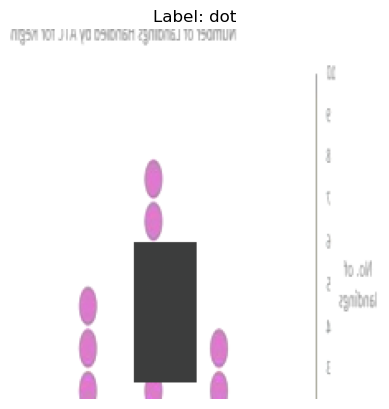

In [74]:
# pick a  batch
for images, labels in train_loader:
    # select the first image in the batch
    image = images[0]  # shape: (3, 224, 224)
    label = labels[0].item()

    # Denormalize
    unnormalize = transforms.Compose([
        transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
    ])
    image = unnormalize(image)

    image = image.permute(1, 2, 0).numpy()#(224, 224, 3)


    plt.imshow(image)
    plt.title(f"Label: {cfg.__dict__[str(label)]}")
    plt.axis("off") 
    plt.show()
    
    break

In [75]:
# based off the above version, I prepare add more data processing into dataset
# 1. add original data as input, not only using images after augmentation
# 2. Make sure all original images are taken as input and also add the augmented images
# 3. the augmented images are allowed resampling from original images
# 4. add more augmentation methods into dataset


class ImageClsDataset(Dataset):
    def __init__(
        self,
        hdf5_file: str,
        augment: bool = False,
        augment_prob: float = 0.5,
        ds_total_len: float = 2,
        image_height: int = 224,
        image_width: int = 224,
    ):
        """
        hdf5_file: the path of the hdf5 dataset
        augment: choose if doing augmentation on image or not
        augment_prob: Control augmentation probability
        ds_total_len: Define how many times the amount of data (data augmentation + original data) the dataset will process is the original dataset
            e.g.: ds_total_len=2 represents that this dataset would process 2 times the amount of images than the original dataset size.
                  In other words, to process all original images and the same number of augmented images as original images.
        image_height | image_width: the size of the image as the input into the model
        """
        self.hdf5_file = hdf5_file
        self.augment = augment
        self.augment_prob = augment_prob
        self.ds_total_len=ds_total_len
        self.image_height = image_height
        self.image_width = image_width

        with h5py.File(self.hdf5_file, "r") as hf:
            self.base_length = hf["images"].shape[0]
            # load all labels into memory at one time (high efficiency)
            self.labels = hf["labels"][:]

        # data augmentation
        self.augmentation_transforms = {
            "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
            "Rotation": transforms.RandomRotation(degrees=10),
            "Color Jitter": transforms.ColorJitter(
                brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
            ),
            "Random Erasing": transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
                    transforms.ToPILImage(),
                ]
            ),
        }

        # resizing original images
        self.base_transform = transforms.Resize((self.image_height, self.image_width))

        # normalization(fit for ImageNet pretraining)
        self.normalize_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # process all original images and the same number of augmented images as original images
        self.length = self.ds_total_len * self.base_length 

    def random_resized_crop(self, img):
        """
        Crop the image randomly
        """
        crop_transform = transforms.RandomResizedCrop(
            self.image_width, scale=(0.3, 1.0)
        )

        return crop_transform(img)

    def center_included_random_crop(self, img):
        """
        Ensure random cropping within the center point
        """
        W, H = img.size
        center_x, center_y = (
            W // 2,
            H // 2,
        )  # calculate the center point of the original image

        scale_min, scale_max = 0.3, 0.6  # allowable crop ratio
        crop_ratio = random.uniform(scale_min, scale_max)  # generate the crop ratio
        crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)

        # make sure the original image's center point in the crop frame
        left_min = max(0, center_x - crop_W)
        top_min = max(0, center_y - crop_H)
        left_max = min(W - crop_W, center_x)
        top_max = min(H - crop_H, center_y)

        # random select the crop frame's coordinates
        left = random.randint(left_min, left_max)
        top = random.randint(top_min, top_max)
        right = left + crop_W
        bottom = top + crop_H

        # resizing
        cropped_img = img.crop((left, top, right, bottom))
        resize_transform = transforms.Resize((self.image_height, self.image_width))

        return resize_transform(cropped_img)

    def apply_augmentations(self, img):
        """
        Apply random augmentation to the image
        """
        # random select the cropping method
        crop_methods = [self.random_resized_crop, self.center_included_random_crop]
        img = random.choice(crop_methods)(img)

        # random select other augmentation methods
        num_augmentations = random.randint(1, len(self.augmentation_transforms))
        chosen_augmentations = random.sample(
            list(self.augmentation_transforms.keys()), num_augmentations
        )

        for augmentation in chosen_augmentations:
            img = self.augmentation_transforms[augmentation](img)

        return img

    def __len__(self):
        """
        return the number of data in the dataset
        """
        return self.length

    def __getitem__(self, idx):
        # judge if need do data augmentation (bool)
        is_augmented = idx >= self.base_length

        # if need data augmentation, need to random select an idx from original dataset 
        # and use the original image corresponding to idx for data augmentation to generate the augmented image
        true_idx = idx if not is_augmented else random.randint(0, self.base_length - 1)

        with h5py.File(self.hdf5_file, "r") as hf:
            image = hf["images"][true_idx]
            label = hf["labels"][true_idx]

        # convert NumPy -> PIL（fit with torchvision.transforms）
        image = Image.fromarray(image)

        # resizing first 
        image = self.base_transform(image)

        # data augmentation
        if is_augmented and self.augment:
            image = self.apply_augmentations(image)

        # DO normalization, we use pretained weights, so follow this normalization
        image = self.normalize_transform(image)

        # add idx as one putput temporary, check the correctness
        return image, torch.tensor(label, dtype=torch.long), idx

In [76]:
def compute_class_weights(labels, ds_total_len=2):
    """
    Weighted sampling to balance class distribution
    :param labels: Dataset.labels (np.array)
    :param ds_total_len: Total dataset size multiplier (default = 2x original)
    """
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # calculate each cate's sampling weights (The fewer the samples, the greater the weight)
    class_weights = {label: 1.0 / count for label, count in zip(unique_labels, counts)}
    
    # calculate original images's sample_weights
    sample_weights = np.array([class_weights[label] for label in labels])

    # replicate sample_weights to match `ds_total_len` size
    balanced_sample_weights = np.tile(sample_weights, int(ds_total_len))  

    return balanced_sample_weights

In [77]:
with h5py.File(hdf5_file, "r") as hf:
    length = hf["images"].shape[0]

train_dataset = ImageClsDataset(hdf5_file, augment=True,ds_total_len=ds_multiplier)

# calculate the sampling weights
sample_weights = compute_class_weights(train_dataset.labels, ds_total_len=ds_multiplier)
# generate sampler
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0,pin_memory=True
)

for images, labels, indices in train_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Batch indices: {indices}")
    print(f"If original images: {['original' if idx < length else 'augmented' for idx in indices]}")  # (32, 3, 224, 224)
    break

Batch shape: torch.Size([32, 3, 224, 224])
Batch indices: tensor([ 15779,  21001,  70152,  25465,  89101,  97420,  42974,   8466,  11763,
        111178, 111256,  73582,   5409,   1225,  23143,    645,  96911,  26213,
         91269,  87229,  68412,  82860, 101961,  90094,   8009,  83504,  19030,
        103525,  29584,  97838,  50610, 104202])
If original images: ['original', 'original', 'augmented', 'original', 'augmented', 'augmented', 'original', 'original', 'original', 'augmented', 'augmented', 'augmented', 'original', 'original', 'original', 'original', 'augmented', 'original', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'original', 'augmented', 'original', 'augmented', 'original', 'augmented']


In [78]:
# check the total batches in the iterator
len(train_loader)

3786

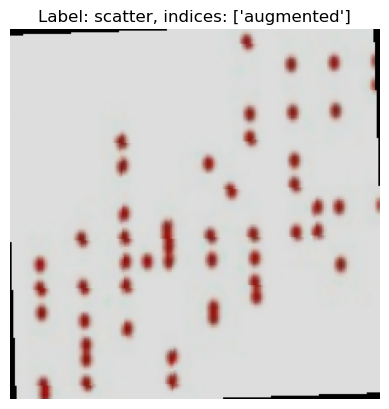

In [79]:
for images, labels, indices in train_loader:
    # select the first image in the batch
    image = images[0]  # shape: (3, 224, 224)
    label = labels[0].item()

    # Denormalize
    unnormalize = transforms.Compose([
        transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
    ])
    image = unnormalize(image)

    image = image.permute(1, 2, 0).numpy()#(224, 224, 3)


    plt.imshow(image)
    plt.title(f"Label: {cfg.__dict__[str(label)]}, indices: {['original' if indices[0] < length else 'augmented']}")
    plt.axis("off") 
    plt.show()
    
    break

In [80]:
# plan using more augmented images in batch in early-stage training, and using more original images at the late-stage, to imporve the model's robust


class ImageClsDataset(Dataset):
    def __init__(
        self,
        hdf5_file: str,
        augment: bool = False,
        ds_total_len: float = 2,
        image_height: int = 224,
        image_width: int = 224,
    ):
        """
        hdf5_file: the path of the hdf5 dataset
        augment: choose if doing augmentation on image or not
        ds_total_len: Define how many times the amount of data (data augmentation + original data) the dataset will process is the original dataset
            e.g.: ds_total_len=2 represents that this dataset would process 2 times the amount of images than the original dataset size.
                  In other words, to process all original images and the same number of augmented images as original images.
        image_height | image_width: the size of the image as the input into the model
        """
        self.hdf5_file = hdf5_file
        self.augment = augment
        self.ds_total_len = ds_total_len
        self.image_height = image_height
        self.image_width = image_width

        with h5py.File(self.hdf5_file, "r") as hf:
            self.base_length = hf["images"].shape[0]
            # load all labels into memory at one time (high efficiency)
            self.labels = hf["labels"][:]

        # data augmentation
        self.augmentation_transforms = {
            "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
            "Rotation": transforms.RandomRotation(degrees=10),
            "Color Jitter": transforms.ColorJitter(
                brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
            ),
            "Random Erasing": transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
                    transforms.ToPILImage(),
                ]
            ),
        }

        # resizing original images
        self.base_transform = transforms.Resize((self.image_height, self.image_width))

        # normalization(fit for ImageNet pretraining)
        self.normalize_transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        # process all original images and the same number of augmented images as original images
        self.length = self.ds_total_len * self.base_length


    def random_resized_crop(self, img):
        """
        Crop the image randomly
        """
        crop_transform = transforms.RandomResizedCrop(
            self.image_width, scale=(0.3, 1.0)
        )

        return crop_transform(img)

    def center_included_random_crop(self, img):
        """
        Ensure random cropping within the center point
        """
        W, H = img.size
        center_x, center_y = (
            W // 2,
            H // 2,
        )  # calculate the center point of the original image

        scale_min, scale_max = 0.3, 0.6  # allowable crop ratio
        crop_ratio = random.uniform(scale_min, scale_max)  # generate the crop ratio
        crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)

        # make sure the original image's center point in the crop frame
        left_min = max(0, center_x - crop_W)
        top_min = max(0, center_y - crop_H)
        left_max = min(W - crop_W, center_x)
        top_max = min(H - crop_H, center_y)

        # random select the crop frame's coordinates
        left = random.randint(left_min, left_max)
        top = random.randint(top_min, top_max)
        right = left + crop_W
        bottom = top + crop_H

        # resizing
        cropped_img = img.crop((left, top, right, bottom))
        resize_transform = transforms.Resize((self.image_height, self.image_width))

        return resize_transform(cropped_img)

    def apply_augmentations(self, img):
        """
        Apply random augmentation to the image
        """

        # random select the cropping method
        crop_methods = [self.random_resized_crop, self.center_included_random_crop]
        img = random.choice(crop_methods)(img)

        # random select other augmentation methods
        num_augmentations = random.randint(1, len(self.augmentation_transforms))
        chosen_augmentations = random.sample(
            list(self.augmentation_transforms.keys()), num_augmentations
        )

        for augmentation in chosen_augmentations:
            img = self.augmentation_transforms[augmentation](img)

        return img
    

    def __len__(self):
        """
        return the number of data in the dataset
        """
        return self.length

    def __getitem__(self, idx):
        # judge if need do data augmentation (bool)
        is_augmented = idx >= self.base_length

        # if need data augmentation, need to map the idx into original dataset (subtract base_length)
        # and use the original image corresponding to idx for data augmentation to generate the augmented image
        true_idx = idx if not is_augmented else int(idx-int(self.base_length))

        with h5py.File(self.hdf5_file, "r") as hf:
            image = hf["images"][true_idx]
            label = hf["labels"][true_idx]

        # convert NumPy -> PIL（fit with torchvision.transforms）
        image = Image.fromarray(image)

        # resizing first
        image = self.base_transform(image)

        # data augmentation
        if is_augmented and self.augment:
            image = self.apply_augmentations(image)

        # DO normalization, we use pretained weights, so follow this normalization
        image = self.normalize_transform(image)

        # add idx as one putput temporary, check the correctness
        return image, torch.tensor(label, dtype=torch.long), idx

In [ ]:
def compute_class_weights(labels, ds_total_len=2, augment_prob=0.5):
    """
    Compute sampling weights for original and augmented data.
    Params:
       labels: np.array, original dataset labels
        ds_total_len: Dataset size multiplier (default = 2x original)
        augment_prob: Probability of selecting augmented samples
    """
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Calculate the category sampling weight (the fewer category samples, the greater the weight)
    class_weights = {label: 1.0 / count for label, count in zip(unique_labels, counts)}

    # Original data weight
    original_sample_weights = np.array([class_weights[label] for label in labels])

    # Copy labels so that augmented_labels and original_labels keep the same category ratio
    augmented_labels = np.tile(labels, max(int(ds_total_len - 1), 1))
    augmented_sample_weights = np.array([class_weights[label] for label in augmented_labels])

    # Calculate how much original` vs. augmented should be in batch
    num_original = len(original_sample_weights)
    num_augmented = len(augmented_sample_weights)
    total_samples = num_original + num_augmented

    # Control the proportion of augmented data in batch
    if num_augmented == 0:
        augmented_ratio = 0
    else:
        augmented_ratio = augment_prob * total_samples / num_augmented

    original_ratio = (1 - augment_prob) * total_samples / num_original

    final_sample_weights = np.concatenate([
        original_sample_weights * original_ratio,  
        augmented_sample_weights * augmented_ratio 
    ])

    return final_sample_weights

In [82]:
# train_dataset = ImageClsDataset(
#     hdf5_file, augment=True, ds_total_len=2
# )

# labels=train_dataset.labels
# print(len(labels))
# unique_labels, counts = np.unique(labels, return_counts=True)
# print(unique_labels,counts)

# class_weights = {label: 1.0 / count for label, count in zip(unique_labels, counts)}
# print(class_weights)

# original_sample_weights = np.array([class_weights[label] for label in labels])
# print(original_sample_weights)
# print(len(original_sample_weights))

# augmented_labels = np.tile(labels, max(int(2 - 1), 1))
# print(augmented_labels)
# print(len(augmented_labels))

# augmented_sample_weights = np.array([class_weights[label] for label in augmented_labels])
# print(augmented_sample_weights)

# num_original = len(original_sample_weights)
# print(num_original)

# num_augmented = len(augmented_sample_weights)
# print(num_augmented)


# augmented_ratio = 0.8 * (num_original + num_augmented) / num_augmented
# print(augmented_ratio)

# original_ratio = (1 - 0.8) * (num_original + num_augmented) / num_original
# print(original_ratio)


# final_sample_weights = np.concatenate([
#     original_sample_weights * original_ratio,  
#     augmented_sample_weights * augmented_ratio  
# ])

# print(final_sample_weights)
# print(len(final_sample_weights))

In [83]:
from collections import Counter

with h5py.File(hdf5_file, "r") as hf:
    length = hf["images"].shape[0]


num_epochs = 50
initial_augment_prob = 0.8  # initilize the augmentation ratio
final_augment_prob = 0.3  # decrease the augmentation ratio at late stage

# initilize train_dataset
train_dataset = ImageClsDataset(hdf5_file, augment=True, ds_total_len=ds_multiplier)

for epoch in range(num_epochs):
    # update the augmentation parameters dynamically
    current_augment_prob = initial_augment_prob - (epoch / num_epochs) * (
        initial_augment_prob - final_augment_prob
    )
    print("current_augment_prob: ", current_augment_prob)

    # update sample_weights
    sample_weights = compute_class_weights(
        labels=train_dataset.labels,
        ds_total_len=ds_multiplier,
        augment_prob=current_augment_prob,
    )

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True,  # **temporary set as true, may change later**
    )

    # generate DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=True,
    )

    for images, labels, indices in train_loader:
        # print(f"Batch shape: {images.shape}")
        # print(f"Batch indices: {indices}")
        print(
            f"If original images: {['original' if idx < length else 'augmented' for idx in indices]}"
        )  # (32, 3, 224, 224)
        print(
            "augmented/original ratio",
            Counter(["original" if idx < length else "augmented" for idx in indices]),
        )
        logging.info(
            f"Batch info, augmented-original counting: {Counter(['original' if idx < length else 'augmented' for idx in indices])}"
        )
        break

    print(f"Epoch {epoch+1}/{num_epochs} - Augment Prob: {current_augment_prob:.2f}")

    # # traing loop
    # for images, labels in train_loader:
    #     # training...
    #     pass

current_augment_prob:  0.8
If original images: ['augmented', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'original', 'augmented', 'augmented', 'original', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'augmented', 'original', 'original', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'original']
augmented/original ratio Counter({'augmented': 24, 'original': 8})
Epoch 1/50 - Augment Prob: 0.80
current_augment_prob:  0.79
If original images: ['augmented', 'augmented', 'augmented', 'original', 'original', 'augmented', 'original', 'augmented', 'original', 'original', 'augmented', 'original', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'augmented', 'augmented', 'original', 'augmented', 'augmented', 'original', 'original', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented', 'au

In [255]:
# enable GPU
if torch.backends.mps.is_available():
    print("✅ MPS (Metal Performance Shaders) is available!")
    device = torch.device("mps") 
else:
    print("MPS is not available. Using CPU.")
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")

x = torch.rand(3, 3).to(device)
print(f"Tensor on device: {x.device}")

✅ MPS (Metal Performance Shaders) is available!
PyTorch version: 2.2.0
Tensor on device: mps:0


In [256]:
print(device)
print(type(device))

mps
<class 'torch.device'>


In [257]:
# add train/val split
# add indices into constructor that allow me to send the train/val indices into dataset

class ImageClsDataset(Dataset):
    def __init__(
        self,
        hdf5_file: str,
        augment: bool = False,
        indices: np.ndarray = None,
        ds_total_len: float = 2,
        image_height: int = 224,
        image_width: int = 224,
        device: torch.device = torch.device("cpu")
    ):
        """
        hdf5_file: the path of the hdf5 dataset
        augment: choose if doing augmentation on image or not
        indices: used to split the train/val dataset
        ds_total_len: Define how many times the amount of data (data augmentation + original data) the dataset will process is the original dataset
            e.g.: ds_total_len=2 represents that this dataset would process 2 times the amount of images than the original dataset size.
                  In other words, to process all original images and the same number of augmented images as original images.
        image_height | image_width: the size of the image as the input into the model
        device: the CPU/GPU device
        """
        self.hdf5_file = hdf5_file
        self.augment = augment
        self.indices=indices
        self.ds_total_len = ds_total_len
        self.image_height = image_height
        self.image_width = image_width
        self.device=device

        with h5py.File(self.hdf5_file, "r") as hf:
            self.base_length = hf["images"].shape[0]
            # load all labels into memory at one time (high efficiency)
            self.labels = hf["labels"][:]

        # if without given indices, do not do any operations on dataset
        if self.indices is None:
            self.indices = np.arange(len(self.labels))

        # if with indices, update the labels and dataset length
        self.labels = self.labels[self.indices]  
        self.base_length = len(self.indices)  

        # data augmentation
        self.augmentation_transforms = {
            "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
            "Rotation": transforms.RandomRotation(degrees=10),
            "Color Jitter": transforms.ColorJitter(
                brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
            ),
            "Random Erasing": transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
                    transforms.ToPILImage(),
                ]
            ),
        }

        # resizing original images
        self.base_transform = transforms.Resize((self.image_height, self.image_width))

        # normalization(fit for ImageNet pretraining)
        self.normalize_transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        # process all original images and the same number of augmented images as original images
        self.length = self.ds_total_len * self.base_length


    def random_resized_crop(self, img):
        """
        Crop the image randomly
        """
        crop_transform = transforms.RandomResizedCrop(
            self.image_width, scale=(0.3, 1.0)
        )

        return crop_transform(img)

    def center_included_random_crop(self, img):
        """
        Ensure random cropping within the center point
        """
        W, H = img.size
        center_x, center_y = (
            W // 2,
            H // 2,
        )  # calculate the center point of the original image

        scale_min, scale_max = 0.3, 0.6  # allowable crop ratio
        crop_ratio = random.uniform(scale_min, scale_max)  # generate the crop ratio
        crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)

        # make sure the original image's center point in the crop frame
        left_min = max(0, center_x - crop_W)
        top_min = max(0, center_y - crop_H)
        left_max = min(W - crop_W, center_x)
        top_max = min(H - crop_H, center_y)

        # random select the crop frame's coordinates
        left = random.randint(left_min, left_max)
        top = random.randint(top_min, top_max)
        right = left + crop_W
        bottom = top + crop_H

        # resizing
        cropped_img = img.crop((left, top, right, bottom))
        resize_transform = transforms.Resize((self.image_height, self.image_width))

        return resize_transform(cropped_img)

    def apply_augmentations(self, img):
        """
        Apply random augmentation to the image
        """

        # random select the cropping method
        crop_methods = [self.random_resized_crop, self.center_included_random_crop]
        img = random.choice(crop_methods)(img)

        # random select other augmentation methods
        num_augmentations = random.randint(1, len(self.augmentation_transforms))
        chosen_augmentations = random.sample(
            list(self.augmentation_transforms.keys()), num_augmentations
        )

        for augmentation in chosen_augmentations:
            img = self.augmentation_transforms[augmentation](img)

        return img
    

    def __len__(self):
        """
        return the number of data in the dataset
        """
        return self.length

    def __getitem__(self, idx):
        # judge if need do data augmentation (bool)
        is_augmented = idx >= self.base_length

        # if need data augmentation, need to map the idx into original dataset (subtract base_length)
        # and use the original image corresponding to idx for data augmentation to generate the augmented image
        true_idx = idx if not is_augmented else int(idx-int(self.base_length))

        with h5py.File(self.hdf5_file, "r") as hf:
            image = hf["images"][self.indices[true_idx]]
            label = self.labels[true_idx]

        # convert NumPy -> PIL（fit with torchvision.transforms）
        image = Image.fromarray(image)

        # resizing first
        image = self.base_transform(image)

        # data augmentation
        if is_augmented and self.augment:
            image = self.apply_augmentations(image)

        # DO normalization, we use pretained weights, so follow this normalization
        image = self.normalize_transform(image)

        # add idx as one putput temporary, check the correctness
        return image.to(self.device), torch.tensor(label, dtype=torch.long, device=self.device), idx

In [265]:
class ImageClsDataModule(L.LightningDataModule):
    def __init__(
        self,
        hdf5_file: str,
        batch_size=32,
        train_ratio=0.8,
        ds_total_len=2.0,
        initial_augment_prob=0.8,
        final_augment_prob=0.3,
        num_epochs=50,
        device: torch.device = torch.device("cpu"),
        num_workers: int = 0,
    ):
        """
        Params:
            hdf5_file: the path of the hdf5 dataset
            batch_size: size of batch
            train_ratio: train/val dataset ratio
            ds_total_len: Define how many times the amount of data (data augmentation + original data) the dataset will process is the original dataset
                e.g.: ds_total_len=2 represents that this dataset would process 2 times the amount of images than the original dataset size.
                    In other words, to process all original images and the same number of augmented images as original images.
            initial_augment_prob: Initial data augmentation ratio
            final_augment_prob: final data augmentation ratio
            num_epochs: the number of epochs
            device: USE GPU/CPU deivce
            num_worker: the number of workers for dataloader
        """
        super().__init__()
        self.hdf5_file = hdf5_file
        self.batch_size = batch_size
        self.train_ratio = train_ratio
        self.ds_total_len = ds_total_len
        self.initial_augment_prob = initial_augment_prob
        self.final_augment_prob = final_augment_prob
        self.num_epochs = num_epochs
        self.device = device
        self.num_workers = num_workers

        self.current_epoch = 0

    def setup(self, stage=None):
        """
        Split dataset into train and testsets
        """

        with h5py.File(self.hdf5_file, "r") as hf:
            labels = np.array(hf["labels"])
            num_samples = len(labels)

        # ensure the label balancing
        train_indices, val_indices = train_test_split(
            np.arange(num_samples),
            test_size=1 - self.train_ratio,
            stratify=labels,
            random_state=42,
        )

        # create train and val dataset
        self.train_dataset = ImageClsDataset(
            self.hdf5_file,
            indices=train_indices,
            augment=True,
            ds_total_len=self.ds_total_len,
            device=self.device,
        )

        self.val_dataset = ImageClsDataset(
            self.hdf5_file,
            indices=val_indices,
            augment=False,
            # hard coded as 1 because onlu use original images in val set
            ds_total_len=1,
            device=self.device,
        )

    def update_augment_prob(self):
        """
        update the augmented ratio for each epoch

        use more augmented images in early-stage epoches.
        use fewer augmented images in late-stage epoches.
        """
        # sync the current training epoch
        if self.trainer is not None:
            self.current_epoch = self.trainer.current_epoch

        self.augment_prob = self.initial_augment_prob - (
            self.current_epoch / self.num_epochs
        ) * (self.initial_augment_prob - self.final_augment_prob)

        print(f"📢 Epoch {self.current_epoch}: Augment Prob = {self.augment_prob:.2f}")
        logging.info(
            f"📢 Epoch {self.current_epoch}: Augment Prob = {self.augment_prob:.2f}"
        )

        return None

    def train_dataloader(self):
        """
        define how the dataloader created for each epoch
        requirements:
            set `reload_dataloaders_every_n_epochs=1` in L.trainer
        """
        # calculate the current epoch's augment ratio
        self.update_augment_prob()
        # self.train_dataset.update_augment_prob(self.augment_prob)

        # re-build the sampler
        sample_weights = compute_class_weights(
            labels=self.train_dataset.labels,
            ds_total_len=self.ds_total_len,
            augment_prob=self.augment_prob,
        )

        train_sampler = WeightedRandomSampler(
            sample_weights, num_samples=len(sample_weights), replacement=True
        )
        print(
            f"TRAIN_DATALODER DATAMODULE FLAG (current epoch num): {self.current_epoch+1}"
        )

        logging.info(
            f"TRAIN_DATALODER DATAMODULE FLAG (current epoch num): {self.current_epoch+1}"
        )

        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            sampler=train_sampler,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        """
        define how the validation dataloader created for each epoch
        requirements:
            set `reload_dataloaders_every_n_epochs=1` in L.trainer
        """
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def count_train_augmented_original_ratio(self):
        """
        TEST

        check the data distribution in each dataloader
        : if the number of original data and augmented data could fit with the expection
        """
        length = self.train_dataset.base_length
        dataloader = self.train_dataloader()

        for images, labels, indices in dataloader:
            print(
                f"TRAIN: If original images:{['original' if idx < length else 'augmented' for idx in indices]}"
            )
            logging.info(
                f"TRAIN: If original images:{['original' if idx < length else 'augmented' for idx in indices]}"
            )
            print(
                f"TRAIN: augmented/original ratio: {Counter(['original' if idx < length else 'augmented' for idx in indices])}"
            )
            logging.info(
                f"TRAIN: augmented/original ratio: {Counter(['original' if idx < length else 'augmented' for idx in indices])}"
            )
            break

        print(
            f"TRAIN: Epoch {self.current_epoch+1}/{self.num_epochs} - Augment Prob: {self.augment_prob:.2f}"
        )
        logging.info(
            f"TRAIN: Epoch {self.current_epoch+1}/{self.num_epochs} - Augment Prob: {self.augment_prob:.2f}"
        )

        return None

    def count_val_augmented_original_ratio(self):
        """
        TEST

        check the data distribution in each dataloader
        : if the number of original data and augmented data could fit with the expection
        """
        length = self.val_dataset.base_length
        dataloader = self.val_dataloader()

        for images, labels, indices in dataloader:
            print(
                f"VALIDATION: If original images:{['original' if idx < length else 'augmented' for idx in indices]}"
            )
            logging.info(
                f"VALIDATION: If original images:{['original' if idx < length else 'augmented' for idx in indices]}"
            )

            print(
                f"VALIDATION: augmented/original ratio{Counter(['original' if idx < length else 'augmented' for idx in indices])}"
            )
            logging.info(f"VALIDATION: augmented/original ratio: {Counter(['original' if idx < length else 'augmented' for idx in indices])}"
            )
            break

        return None

    def on_train_epoch_start(self):
        """
        sync the self.current_epoch value with the trainer
        """
        if self.trainer is not None:
            self.current_epoch = (
                self.trainer.current_epoch
            )  # sync the current training epoch
            self.update_augment_prob()

            print(f"\n🔥 Epoch {self.current_epoch+1}/{self.num_epochs}")
            print(f"📢 Augment Prob = {self.augment_prob:.2f}")

        return None

In [266]:
num_epochs = 5
batch_size = 32
ds_total_len = 2.0
initial_augment_prob = 0.8
final_augment_prob = 0.3

datamodule = ImageClsDataModule(
    hdf5_file=hdf5_file,
    batch_size=batch_size,
    ds_total_len=ds_total_len,
    initial_augment_prob=initial_augment_prob,
    final_augment_prob=final_augment_prob,
    num_epochs=num_epochs,
    device=device,
    num_workers=0
)

# manual trigger setup()
# datamodule.setup()

In [267]:
class FakeModel(L.LightningModule):
    '''
    create a fake model to test the DataSet and DataModule
    '''
    def __init__(self, datamodule):
        super().__init__()
        self.dummy_layer = nn.Linear(1, 1) 
        self.datamodule = datamodule

    def forward(self, x):
        return self.dummy_layer(x)

    def training_step(self, batch, batch_idx):
        # invoke function to check the current epoch
        # self.datamodule.on_train_epoch_start()

        # load the data in each batch, only print batch
        images, labels, indices=batch

        print(f"training_step: images shape in the batch: {images.shape}")
        logging.info(f"training_step: images shape in the batch: {images.shape}")

        print(f"training_step: labels in the batch: {labels}")
        logging.info(f"training_step: labels in the batch: {labels}")

        print(f"training_step: corresponding indices of data in this batch: {indices}")
        logging.info(f"training_step: corresponding indices of data in this batch: {indices}")

        print(f"training_step: batch index: {batch_idx}")
        logging.info(f"training_step: batch index: {batch_idx}")

        self.datamodule.count_train_augmented_original_ratio()
        
        return None 
    
    def validation_step(self,batch,batch_idx):
        images,labels,indices=batch

        print(f"validation_step: images shape in the batch: {images.shape}")
        logging.info(f"validation_step: images shape in the batch: {images.shape}")

        print(f"validation_step: labels in the batch: {labels}")
        logging.info(f"validation_step: labels in the batch: {labels}")

        print(f"validation_step: corresponding indices of data in this batch: {indices}")
        logging.info(f"validation_step: corresponding indices of data in this batch: {indices}")

        print(f"validation_step: batch index: {batch_idx}")
        logging.info(f"validation_step: batch index: {batch_idx}")
        
        self.datamodule.count_val_augmented_original_ratio()
        
        return None

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=0.1)  

In [268]:
model = FakeModel(datamodule)

In [271]:
logging.info("***************************************** trainer logs ******************************************")
logging.info("***************************************** trainer logs ******************************************")
logging.info("***************************************** trainer logs ******************************************")
logging.info("***************************************** trainer logs ******************************************")
trainer = L.Trainer(
    max_epochs=num_epochs, 
    limit_train_batches=10,
    limit_val_batches=10,
    reload_dataloaders_every_n_epochs=1, 
    enable_checkpointing=False, 
    logger=False,
    enable_progress_bar=True 
)

trainer.fit(model, datamodule)


  | Name        | Type   | Params | Mode 
-----------------------------------------------
0 | dummy_layer | Linear | 2      | train
-----------------------------------------------
2         Trainable params
0         Non-trainable params
2         Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


validation_step: images shape in the batch: torch.Size([32, 3, 224, 224])
validation_step: labels in the batch: tensor([3, 3, 3, 1, 4, 0, 3, 4, 4, 0, 3, 3, 4, 0, 3, 3, 4, 3, 4, 4, 0, 1, 3, 3,
        4, 3, 0, 0, 3, 0, 1, 4], device='mps:0')
validation_step: corresponding indices of data in this batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='mps:0')
validation_step: batch index: 0
VALIDATION: If original images:['original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original']
VALIDATION: augmented/original ratioCounter({'original': 32})
validation_step: im

/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

validation_step: images shape in the batch: torch.Size([32, 3, 224, 224])
validation_step: labels in the batch: tensor([3, 3, 3, 1, 4, 0, 3, 4, 4, 0, 3, 3, 4, 0, 3, 3, 4, 3, 4, 4, 0, 1, 3, 3,
        4, 3, 0, 0, 3, 0, 1, 4], device='mps:0')
validation_step: corresponding indices of data in this batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='mps:0')
validation_step: batch index: 0
VALIDATION: If original images:['original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original']
VALIDATION: augmented/original ratioCounter({'original': 32})
validation_step: im

Validation: |          | 0/? [00:00<?, ?it/s]

validation_step: images shape in the batch: torch.Size([32, 3, 224, 224])
validation_step: labels in the batch: tensor([3, 3, 3, 1, 4, 0, 3, 4, 4, 0, 3, 3, 4, 0, 3, 3, 4, 3, 4, 4, 0, 1, 3, 3,
        4, 3, 0, 0, 3, 0, 1, 4], device='mps:0')
validation_step: corresponding indices of data in this batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='mps:0')
validation_step: batch index: 0
VALIDATION: If original images:['original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original']
VALIDATION: augmented/original ratioCounter({'original': 32})
validation_step: im

Validation: |          | 0/? [00:00<?, ?it/s]

validation_step: images shape in the batch: torch.Size([32, 3, 224, 224])
validation_step: labels in the batch: tensor([3, 3, 3, 1, 4, 0, 3, 4, 4, 0, 3, 3, 4, 0, 3, 3, 4, 3, 4, 4, 0, 1, 3, 3,
        4, 3, 0, 0, 3, 0, 1, 4], device='mps:0')
validation_step: corresponding indices of data in this batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='mps:0')
validation_step: batch index: 0
VALIDATION: If original images:['original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original', 'original']
VALIDATION: augmented/original ratioCounter({'original': 32})
validation_step: im